In [1]:
import pandas as pd
import numpy as np
import os
import glob
import matplotlib.pyplot as plt
import seaborn as sns

# ИИ инструменты
from sklearn.preprocessing import StandardScaler
from sklearn.cluster import KMeans
from sklearn.decomposition import PCA

In [2]:
DATASET_PATH = '/home/lolkek3310/python/Подготовка Гомель/боты/N-BaIoT'
SAMPLE_SIZE = 5000 # Количество строк из каждого файла

def load_data_unsupervised(path, n_rows):
    all_files = glob.glob(os.path.join(path, "*.csv"))
    data_list = []
    
    for f in all_files:
        if any(skip in f for skip in ['summary', 'info', 'features', 'LightGBM']):
            continue
        
        temp_df = pd.read_csv(f)
        temp_df = temp_df.sample(n=min(len(temp_df), n_rows), random_state=42)
        
        # Сохраняем реальную метку только для финальной проверки
        temp_df['real_target'] = 0 if 'benign' in f else 1
        data_list.append(temp_df)
        
    return pd.concat(data_list, ignore_index=True)

df = load_data_unsupervised(DATASET_PATH, SAMPLE_SIZE)
# Удаляем реальную метку из данных для обучения
X_raw = df.drop('real_target', axis=1)
print(f"Загружено записей: {X_raw.shape[0]}")

Загружено записей: 445000


In [3]:
# 1. Удаляем дублирующие признаки (корреляция > 0.98)
corr = X_raw.corr().abs()
upper = corr.where(np.triu(np.ones(corr.shape), k=1).astype(bool))
to_drop = [column for column in upper.columns if any(upper[column] > 0.98)]
X_cleaned = X_raw.drop(to_drop, axis=1)

# 2. Центрирование и Масштабирование
# Превращаем данные так, чтобы среднее было 0, а разброс 1. 
# Теперь алгоритм видит именно ПОВЕДЕНИЕ, а не просто масштаб чисел.
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X_cleaned)

In [4]:
# Обучаем модель находить 3 типа поведения
km = KMeans(n_clusters=3, random_state=42, n_init=10)
clusters = km.fit_predict(X_scaled)

# Добавляем метку кластера в таблицу
X_cleaned['cluster'] = clusters

In [5]:
# Группируем признаки по кластерам и считаем среднее
cluster_stats = X_cleaned.groupby('cluster').mean()

# Ищем колонки, отвечающие за интенсивность трафика (weight)
weight_cols = [c for c in cluster_stats.columns if 'weight' in c]
# Считаем среднюю интенсивность для каждого кластера
intensity_scores = cluster_stats[weight_cols].mean(axis=1)

# Кластер с самой высокой интенсивностью помечаем как БОТНЕТ
botnet_cluster = intensity_scores.idxmax()

print("\n--- ОПРЕДЕЛЕНИЕ ОПАСНОСТИ ПО ПОВЕДЕНИЮ ---")
for i in range(3):
    verdict = "!!! БОТНЕТ (АТАКА) !!!" if i == botnet_cluster else "НОРМАЛЬНО"
    print(f"Кластер {i}: {verdict} | Уровень интенсивности: {intensity_scores[i]:.2f}")


--- ОПРЕДЕЛЕНИЕ ОПАСНОСТИ ПО ПОВЕДЕНИЮ ---
Кластер 0: НОРМАЛЬНО | Уровень интенсивности: 2545.46
Кластер 1: НОРМАЛЬНО | Уровень интенсивности: 141.52
Кластер 2: !!! БОТНЕТ (АТАКА) !!! | Уровень интенсивности: 6478.73


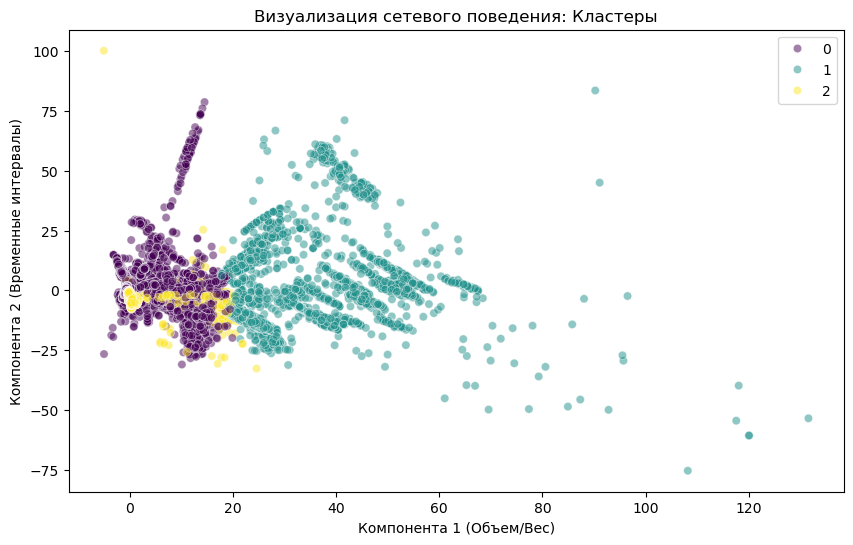

In [6]:
pca = PCA(n_components=2)
X_pca = pca.fit_transform(X_scaled)

plt.figure(figsize=(10, 6))
sns.scatterplot(x=X_pca[:, 0], y=X_pca[:, 1], hue=clusters, palette='viridis', alpha=0.5)
plt.title('Визуализация сетевого поведения: Кластеры')
plt.xlabel('Компонента 1 (Объем/Вес)')
plt.ylabel('Компонента 2 (Временные интервалы)')
plt.show()

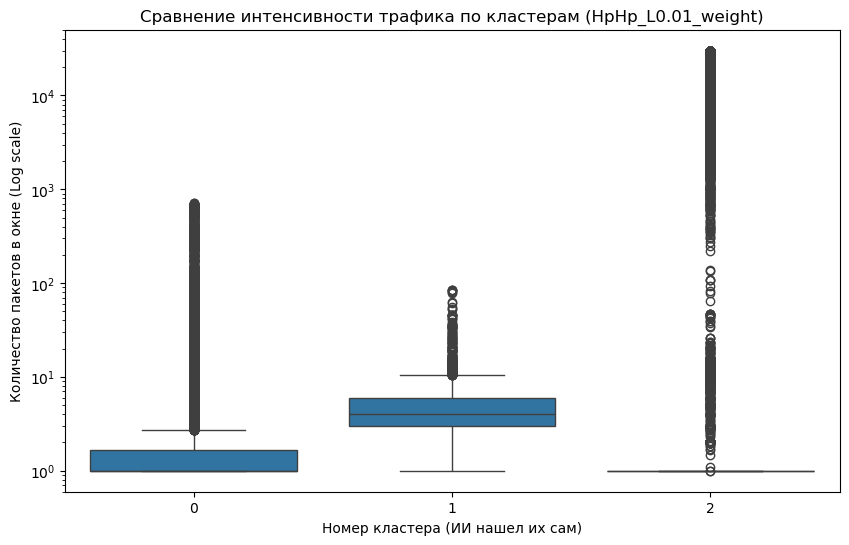

In [7]:
plt.figure(figsize=(10, 6))
# Берем один из самых важных признаков веса
feature_to_plot = 'HpHp_L0.01_weight' if 'HpHp_L0.01_weight' in X_cleaned.columns else weight_cols[0]

sns.boxplot(x='cluster', y=feature_to_plot, data=X_cleaned)
plt.yscale('log') # Логарифмическая шкала, так как разница в ботнетах огромна
plt.title(f'Сравнение интенсивности трафика по кластерам ({feature_to_plot})')
plt.ylabel('Количество пакетов в окне (Log scale)')
plt.xlabel('Номер кластера (ИИ нашел их сам)')
plt.show()

In [8]:
check_df = pd.DataFrame({'AI_Cluster': clusters, 'Real_Label': df['real_target']})
cross_tab = pd.crosstab(check_df['AI_Cluster'], check_df['Real_Label'])

print("\n--- ПРОВЕРКА: КЛАСТЕРЫ VS РЕАЛЬНОСТЬ ---")
print(cross_tab)


--- ПРОВЕРКА: КЛАСТЕРЫ VS РЕАЛЬНОСТЬ ---
Real_Label      0       1
AI_Cluster               
0           41716  295674
1            2610     218
2             674  104108
